# Qwen 2.5 32B Baseline Full-Corpus Run

Notebook de référence pour un run complet du corpus avec `Qwen/Qwen2.5-32B-Instruct` sur 4 GPUs.
Objectif : produire les scores complets, les métriques de parsing et de throughput, ainsi que les diagnostics de tendances annuelles, marques, électrification et répétition des créas.

## 1) Runtime et configuration (multi-GPU, workers, threads)

## Things To Check And Change Before Running Again

This cell controls the runtime environment, the model choice, the GPU usage, and the output locations. Before launching a new run, I should review the following items.

### 1. GPU configuration
- `os.environ["CUDA_VISIBLE_DEVICES"] = '0,1,2,3'`
- This defines which GPUs are visible to the notebook.
- Keep this as `0,1,2,3` if I am using 4 GPUs.
- Change it only if:
  - I have fewer GPUs available
  - I want to restrict the run to fewer devices
  - the server uses different GPU indices

### 2. vLLM multiprocessing
- `os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = '1'`
- This should normally stay enabled for multi-GPU execution.
- It helps vLLM manage parallel inference more reliably.

### 3. CPU / MKL compatibility
- `os.environ["MKL_THREADING_LAYER"] = 'GNU'`
- `os.environ["MKL_SERVICE_FORCE_INTEL"] = '1'`
- These settings help avoid CPU-library conflicts.
- I usually do not change them unless the environment has a specific MKL issue.

### 4. Project path
- `PROJECT_ROOT = Path('/home/cbenavent/test/Arcom_rares')`
- This fallback path must match the actual university machine.
- I need to verify that:
  - the project folder exists there
  - it contains the `data/` directory
- If the notebook is launched from the correct project directory, this fallback may not be needed.

### 5. Input dataset
- `DATASET_PATH = PROJECT_ROOT / 'data' / 'annotation_working_master_human_2100_seed.csv'`
- I need to confirm this is the exact CSV I want to score.
- If I test on another file, I must update this path.

### 6. Output location
- `OUTPUT_ROOT = PROJECT_ROOT / 'communication_function_outputs' / 'multi_gpu_vllm_test'`
- This is where all outputs will be saved.
- I should check:
  - that I have write access
  - that there is enough free space
  - that I am not mixing outputs from unrelated experiments

### 7. Model preset selection
- `PRESET_NAME = 'qwen2_5_32b_instruct'`
- This is the main switch for model choice.
- I can change it to:
  - `gemma4_26b`
  - `qwen2_5_32b_instruct`
  - `custom`
- If I want another model, I must use:
  - `PRESET_NAME = 'custom'`
  - and then set `CUSTOM_MODEL_NAME`

### 8. Custom model mode
- `CUSTOM_MODEL_NAME = ''`
- Only used when `PRESET_NAME = 'custom'`
- I must set a valid Hugging Face model name there.

Example:
- `CUSTOM_MODEL_NAME = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'`

### 9. Chat mode
- `CUSTOM_CHAT_MODE = 'hf_auto'`
- Chat mode controls how the prompt is formatted before being sent to the model.
- Available options:
  - `hf_auto`
  - `manual_gemma`
  - `plain`

#### When to use each
- `hf_auto`
  - best default for most Hugging Face instruct/chat models
  - especially for Qwen
- `manual_gemma`
  - useful for Gemma if the automatic HF chat template is missing or unstable
- `plain`
  - useful for debugging or if the model works better without chat formatting

#### What to watch
If results look strange, compare chat modes based on:
- parse success
- JSON cleanliness
- output plausibility
- agreement with human judgment

### 10. Sample size
- `SAMPLE_SIZE = None`
- `None` means full corpus
- For debugging before a full run, I should set a small sample:
  - `100`
  - `300`
  - `500`

Recommended workflow:
- first run a small sample
- then switch to `None` for the full run

### 11. Model name and derived runtime variables
These are built automatically from the preset:
- `MODEL_NAME`
- `CHAT_MODE`
- `MAX_NEW_TOKENS`
- `TENSOR_PARALLEL_SIZE`
- `VLLM_GPU_MEMORY_UTILIZATION`
- `MAX_MODEL_LEN`
- `VLLM_SWAP_SPACE_GB`
- `MODEL_DTYPE`
- `DISABLE_CUSTOM_ALL_REDUCE`

I should mainly review the preset values that feed them.

### 12. Generation length
- `max_new_tokens`
- Current value in the presets: `600`
- This is probably higher than necessary for short JSON outputs.
- Lower values can improve speed and reduce bad generations.

Suggested range:
- `180`
- `220`
- `256`

This is one of the first things worth testing.

### 13. Tensor parallelism
- `tensor_parallel_size`
- Current value: `4`
- This should match the number of GPUs I want to use.
- For the Dauphine setup with 4 GPUs, I should usually keep it at `4`.

### 14. GPU memory utilization
- `gpu_memory_utilization`
- This controls how much GPU memory vLLM is allowed to use.
- Higher:
  - faster / more efficient
  - more risk of out-of-memory
- Lower:
  - safer
  - sometimes slower

Suggested range:
- `0.88` to `0.92`

If the run crashes:
- reduce this first

### 15. Maximum model length
- `max_model_len`
- Current value: `32768`
- This is probably larger than needed for this task.
- Since prompts are short, reducing it may improve efficiency.

Suggested values to test:
- `8192`
- `4096`

### 16. Swap space
- `swap_space_gb`
- Current value: `8`
- This gives vLLM some CPU-side fallback memory.
- Usually fine to keep as is.
- Increase only if large models are unstable.

### 17. Precision
- `dtype`
- Current value: `bfloat16`
- On H100 GPUs this is usually the correct choice.
- I should generally keep this unchanged.

### 18. Distributed compatibility
- `disable_custom_all_reduce`
- This is more of a stability switch than a quality switch.
- Keep the preset value unless I see distributed or communication issues.

### 19. Output folder per model
- `MODEL_SLUG`
- `OUTPUT_DIR = OUTPUT_ROOT / MODEL_SLUG`
- This is created automatically from the model name.
- It prevents different models from overwriting each other.
- I should check that the outputs go into the expected folder.

### 20. Disk space
- `disk = shutil.disk_usage(PROJECT_ROOT)`
- The notebook prints free disk space.
- Before a full run, I should make sure there is enough storage for:
  - raw JSONL
  - CSV outputs
  - plots
  - performance logs

---

## Main Things I Should Actively Tune

If I want to improve quality or runtime, the first parameters to review are:

1. `PRESET_NAME`
2. `CUSTOM_MODEL_NAME`
3. `CUSTOM_CHAT_MODE`
4. `SAMPLE_SIZE`
5. `max_new_tokens`
6. `gpu_memory_utilization`
7. `max_model_len`

---

## Safe First Run Checklist

Before launching a full run, I should confirm:

- correct `PROJECT_ROOT`
- correct `DATASET_PATH`
- correct `PRESET_NAME`
- correct `CHAT_MODE`
- `SAMPLE_SIZE = 100` or `300` for a quick test first
- enough disk space
- 4 GPUs visible
- output folder is correct

---

## Recommended Starting Setup For Qwen Baseline

A practical starting configuration would be:

- `PRESET_NAME = 'qwen2_5_32b_instruct'`
- `CUSTOM_CHAT_MODE = 'hf_auto'`
- `SAMPLE_SIZE = 300` for a quick test
- then full run with `SAMPLE_SIZE = None`

If I want to optimize further later, the best candidates are:
- lower `max_new_tokens`
- lower `max_model_len`
- fine-tune `gpu_memory_utilization`


In [10]:
import os
import json
import re
import shutil
import subprocess
from pathlib import Path
from typing import Any
import pandas as pd
from tqdm import tqdm
from vllm import LLM, SamplingParams
import matplotlib.pyplot as plt

os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "1"
os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"

conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix:
    conda_lib = f"{conda_prefix}/lib"
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("/home/cbenavent/test/Arcom_rares")

DATASET_PATH = PROJECT_ROOT / "data" / "annotation_working_master_human_2100_seed.csv"
OUTPUT_ROOT = PROJECT_ROOT / "communication_function_outputs" / "multi_gpu_vllm_test"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_PRESETS = {
    "gemma4_26b": {
        "model_name": "google/gemma-4-26B-A4B",
        "chat_mode": "manual_gemma",
        "tensor_parallel_size": 4,
        "gpu_memory_utilization": 0.82,
        "max_model_len": 32768,
        "swap_space_gb": 8,
        "dtype": "bfloat16",
        "disable_custom_all_reduce": True,
        "max_new_tokens": 600,
    },
    "qwen2_5_32b_instruct": {
        "model_name": "Qwen/Qwen2.5-32B-Instruct",
        "chat_mode": "hf_auto",
        "tensor_parallel_size": 4,
        "gpu_memory_utilization": 0.90,
        "max_model_len": 32768,
        "swap_space_gb": 8,
        "dtype": "bfloat16",
        "disable_custom_all_reduce": False,
        "max_new_tokens": 600,
    },
    "custom": {
        "model_name": "",
        "chat_mode": "hf_auto",
        "tensor_parallel_size": 4,
        "gpu_memory_utilization": 0.90,
        "max_model_len": 32768,
        "swap_space_gb": 8,
        "dtype": "bfloat16",
        "disable_custom_all_reduce": False,
        "max_new_tokens": 600,
    },
}

PRESET_NAME = "qwen2_5_32b_instruct"
CUSTOM_MODEL_NAME = ""
CUSTOM_CHAT_MODE = "hf_auto"
SAMPLE_SIZE = None

# Ask for 3 GPUs when available.
TARGET_GPU_COUNT = 3
MIN_GPU_FREE_GB = 35.0

preset = MODEL_PRESETS[PRESET_NAME].copy()
if PRESET_NAME == "custom":
    if not CUSTOM_MODEL_NAME.strip():
        raise ValueError("Set CUSTOM_MODEL_NAME when PRESET_NAME='custom'.")
    preset["model_name"] = CUSTOM_MODEL_NAME.strip()
    preset["chat_mode"] = CUSTOM_CHAT_MODE.strip() or preset["chat_mode"]

MODEL_NAME = preset["model_name"]
CHAT_MODE = preset["chat_mode"]
MAX_NEW_TOKENS = int(preset.get("max_new_tokens", 600))
MAX_MODEL_LEN = preset.get("max_model_len")
VLLM_SWAP_SPACE_GB = preset.get("swap_space_gb", 8)
MODEL_DTYPE = preset.get("dtype", "bfloat16")
DISABLE_CUSTOM_ALL_REDUCE = bool(preset.get("disable_custom_all_reduce", False))


def infer_supported_tp(model_name: str) -> list[int]:
    name = model_name.lower()
    if "qwen2.5-32b" in name:
        # Qwen2.5-32B cannot run with tensor_parallel_size=3.
        return [1, 2, 4, 5, 8]
    if "gemma-4-26b" in name:
        return [1, 2, 4, 8]
    return [1, 2, 3, 4, 6, 8]


def detect_gpu_configuration(
    model_name: str,
    preferred_tp: int,
    target_gpu_count: int = 3,
    min_free_gb: float = 35.0,
):
    query = [
        "nvidia-smi",
        "--query-gpu=index,memory.total,memory.free,name",
        "--format=csv,noheader,nounits",
    ]
    completed = subprocess.run(query, check=True, capture_output=True, text=True)

    stats = []
    for line in completed.stdout.strip().splitlines():
        idx, total_mem, free_mem, gpu_name = [part.strip() for part in line.split(",", 3)]
        total_gb = float(total_mem) / 1024.0
        free_gb = float(free_mem) / 1024.0
        stats.append(
            {
                "index": idx,
                "name": gpu_name,
                "total_gb": total_gb,
                "free_gb": free_gb,
                "free_ratio": free_gb / total_gb if total_gb else 0.0,
            }
        )

    stats.sort(key=lambda x: x["free_gb"], reverse=True)
    eligible = [gpu for gpu in stats if gpu["free_gb"] >= min_free_gb]

    if target_gpu_count < 1:
        target_gpu_count = 1

    selected_count = min(len(eligible), target_gpu_count)
    if selected_count == 0:
        raise RuntimeError(
            f"Not enough free GPUs. Eligible GPUs >= {min_free_gb} GiB: {len(eligible)}"
        )

    supported_tp = sorted(set(infer_supported_tp(model_name)), reverse=True)
    preferred_tp = int(preferred_tp) if int(preferred_tp) > 0 else selected_count

    candidate_tp = []
    for tp in [preferred_tp, selected_count] + supported_tp:
        if tp not in candidate_tp:
            candidate_tp.append(tp)

    tp_size = next(
        (tp for tp in candidate_tp if tp <= selected_count and tp in supported_tp),
        0,
    )
    if tp_size == 0 and 1 in supported_tp:
        tp_size = 1
    if tp_size == 0:
        raise RuntimeError(
            f"No valid tensor_parallel_size for model={model_name} and selected_count={selected_count}"
        )

    selected = eligible[:tp_size]
    min_free_ratio = min(gpu["free_ratio"] for gpu in selected)
    gpu_memory_utilization = min(
        float(preset.get("gpu_memory_utilization", 0.90)),
        max(0.30, round(min_free_ratio - 0.03, 2)),
    )
    return stats, eligible, selected, supported_tp, tp_size, gpu_memory_utilization


GPU_STATS, ELIGIBLE_GPUS, SELECTED_GPUS, SUPPORTED_TP, TENSOR_PARALLEL_SIZE, VLLM_GPU_MEMORY_UTILIZATION = detect_gpu_configuration(
    model_name=MODEL_NAME,
    preferred_tp=int(preset.get("tensor_parallel_size", TARGET_GPU_COUNT)),
    target_gpu_count=TARGET_GPU_COUNT,
    min_free_gb=MIN_GPU_FREE_GB,
)
CUDA_VISIBLE_DEVICES = ",".join(gpu["index"] for gpu in SELECTED_GPUS)
os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES


def slugify_model_name(value: str) -> str:
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


MODEL_SLUG = slugify_model_name(MODEL_NAME)
OUTPUT_DIR = OUTPUT_ROOT / MODEL_SLUG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_KWARGS: dict[str, Any] = {
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "trust_remote_code": True,
    "gpu_memory_utilization": VLLM_GPU_MEMORY_UTILIZATION,
    "dtype": MODEL_DTYPE,
}
if MAX_MODEL_LEN is not None:
    MODEL_KWARGS["max_model_len"] = int(MAX_MODEL_LEN)
# swap_space is deprecated in recent vLLM versions, so it is intentionally not passed.
if DISABLE_CUSTOM_ALL_REDUCE:
    MODEL_KWARGS["disable_custom_all_reduce"] = True

disk = shutil.disk_usage(PROJECT_ROOT)
disk_free_gb = disk.free / (1024**3)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH exists:", DATASET_PATH.exists())
print("Preset:", PRESET_NAME)
print("Model:", MODEL_NAME)
print("CHAT_MODE:", CHAT_MODE)
print("All GPU stats:", GPU_STATS)
print("Eligible GPUs:", ELIGIBLE_GPUS)
print("Selected GPUs:", SELECTED_GPUS)
print("Supported tensor_parallel_size for model:", SUPPORTED_TP)
print("TARGET_GPU_COUNT:", TARGET_GPU_COUNT)
print("TENSOR_PARALLEL_SIZE:", TENSOR_PARALLEL_SIZE)
print("SAMPLE_SIZE:", "ALL" if SAMPLE_SIZE is None else SAMPLE_SIZE)
print("VLLM_GPU_MEMORY_UTILIZATION:", VLLM_GPU_MEMORY_UTILIZATION)
print("MAX_MODEL_LEN:", MAX_MODEL_LEN)
print("VLLM_SWAP_SPACE_GB:", VLLM_SWAP_SPACE_GB)
print("MODEL_DTYPE:", MODEL_DTYPE)
print("OUTPUT_DIR:", OUTPUT_DIR)
print(f"Disk free near PROJECT_ROOT: {disk_free_gb:.1f} GB")
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

try:
    import torch

    if torch.cuda.is_available():
        print(
            "GPUs:",
            torch.cuda.device_count(),
            [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
        )
except Exception as exc:
    print("GPU check skipped:", exc)

PROJECT_ROOT: /home/cbenavent/test/Arcom_rares
DATASET_PATH exists: True
Preset: qwen2_5_32b_instruct
Model: Qwen/Qwen2.5-32B-Instruct
CHAT_MODE: hf_auto
All GPU stats: [{'index': '2', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 42.4072265625, 'free_ratio': 0.45314619638943965}, {'index': '3', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 42.4072265625, 'free_ratio': 0.45314619638943965}, {'index': '1', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 42.0986328125, 'free_ratio': 0.4498486903892309}, {'index': '0', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 0.146484375, 'free_ratio': 0.0015652718355421058}]
Eligible GPUs: [{'index': '2', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 42.4072265625, 'free_ratio': 0.45314619638943965}, {'index': '3', 'name': 'NVIDIA H100 NVL', 'total_gb': 93.583984375, 'free_gb': 42.4072265625, 'free_ratio': 0.45314619638943965}, {'index': '1', 'name': 'NVIDIA H100

In [11]:
#this are the instructiosns given to the model this need to be reviewed again and maybe improved 
RUBRIC_TEXT = """You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
- phatic: social bond, closeness, relationship-maintaining language.

Rules:
- Score each dimension independently from 1 to 5.
- If highest score is tied, dominant_dimension must be mixed.
- dominant_dimension_score must equal the highest score.
- Keep reason short and concrete. 
"""
#the reason should be null or very short i will ask the supervisor how it should be 


DIMENSIONS = ["informativeness", "expressiveness", "phatic"]
SCORE_MIN = 1 
SCORE_MAX = 5

#this used to assure that the model output Json file will be non-ambigous and it pushes the model to return structrued data 
def output_schema_text() -> str:
    return """Return strict JSON only with:
{
  "informativeness": 1,
  "expressiveness": 1,
  "phatic": 1,
  "dominant_dimension": "informativeness|expressiveness|phatic|mixed",
  "dominant_dimension_score": 1,
  "confidence": 0.0,
  "alternative_dimension": "informativeness|expressiveness|phatic|mixed|",
  "reason": "short explanation"
}
"""
# cofidence should be again discussed with the supervisor if it is essential 


## What I Can Change In This Input-Strategy Block

This block controls **which French text columns are sent to the model** and **how they are combined** into `model_input_text`.

---

## 1. Main strategy switch

```python
COLUMN_STRATEGY = "visual_only"


In [12]:
# Choose one:
# - "visual_only"          : use only Visuel
# - "all_french_columns"   : concatenate Script + Incrustation + Titre + Visuel
# - "long_french_text_only": concatenate only French fields whose text has more than 7 tokens

COLUMN_STRATEGY = "visual_only"
MIN_TOKENS_PER_FIELD = 7

TEXT_COLUMNS_FR = ["Script", "Incrustation", "Titre", "Visuel"]

def clean_text(value) -> str:
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def token_count(text: str) -> int:
    if not text:
        return 0
    return len(text.split())

def join_labeled_parts(parts: list[tuple[str, str]]) -> str:
    kept = []
    for label, text in parts:
        text = clean_text(text)
        if text:
            kept.append(f"{label}: {text}")
    return "\n".join(kept).strip()

def build_input_text(row: pd.Series) -> str:
    fr_parts = [(col, row.get(col, "")) for col in TEXT_COLUMNS_FR]

    if COLUMN_STRATEGY == "visual_only":
        return clean_text(row.get("Visuel", ""))

    if COLUMN_STRATEGY == "all_french_columns":
        return join_labeled_parts(fr_parts)

    if COLUMN_STRATEGY == "long_french_text_only":
        selected = []
        for col in TEXT_COLUMNS_FR:
            text = clean_text(row.get(col, ""))
            if token_count(text) > MIN_TOKENS_PER_FIELD:
                selected.append((col, text))
        return join_labeled_parts(selected)

    raise ValueError(f"Unknown COLUMN_STRATEGY: {COLUMN_STRATEGY}")

# Build the model input dataframe
df = pd.read_csv(DATASET_PATH)

required_cols = ["row_id"] + [c for c in TEXT_COLUMNS_FR if c in df.columns]
sample_df = df.loc[:, required_cols].copy()

sample_df["model_input_text"] = sample_df.apply(build_input_text, axis=1)
sample_df = sample_df[sample_df["model_input_text"].str.strip() != ""].copy()


print("COLUMN_STRATEGY:", COLUMN_STRATEGY)
print("MIN_TOKENS_PER_FIELD:", MIN_TOKENS_PER_FIELD)
print("Rows kept:", len(sample_df))
display(sample_df[["row_id", "model_input_text"]].head(3))


COLUMN_STRATEGY: visual_only
MIN_TOKENS_PER_FIELD: 7
Rows kept: 8938


,row_id,model_input_text
0,0,"En caméra cachée, un homme invite des personne..."
1,1,Un homme recharge sa NISSAN LEAF et traverse u...
2,2,Des journalistes interrogent un homme qui vien...


## What I Can Change In This Prompt And Parsing Block

This block controls:
- how the prompt is written
- how the prompt is wrapped for the model
- how the model output is parsed
- how much recovery logic is used when the output is messy

Some parts affect model quality directly. Others affect robustness.

---

## 1. Prompt content: most important for quality

### `RUBRIC_TEXT`
This is one of the most important parts of the whole notebook.

It defines:
- what each dimension means
- how the model should score
- what “dominant dimension” means
- what kind of explanation is expected

### Why it matters
Changing `RUBRIC_TEXT` can change:
- score distributions
- model consistency
- parsing behavior
- agreement with human judgment

### What I can change here
- make the definitions shorter or stricter
- add more precise rules
- add examples
- define the difference between `expressiveness` and `phatic` more clearly
- define how to score mixed ads

### High impact
This is one of the strongest levers for improving annotation quality.

---

## 2. Output schema: important for parsing reliability

### `output_schema_text()`
This defines the exact JSON structure you want back.

### Why it matters
It affects:
- JSON cleanliness
- parse success
- consistency across rows

### What I can change
- remove fields I do not really use
- simplify the structure
- make it shorter if the model struggles

### Good simplification example
If I only care about the 3 scores and dominant dimension, I could remove:
- `confidence`
- `alternative_dimension`
- `reason`

That may improve parsing stability.

### High impact
Good for cleaner outputs and faster generation.

---

## 3. Chat formatting: important for model compatibility

### `GEMMA_CHAT_TEMPLATE`
Used only when:
- `CHAT_MODE = 'manual_gemma'`

### `render_prompt_for_model(...)`
This decides whether the model gets:
- manual Gemma formatting
- Hugging Face auto chat formatting
- plain raw text

### Why it matters
Wrong chat formatting can make a good model behave badly.

### What I can change
- `CHAT_MODE = 'manual_gemma'`
- `CHAT_MODE = 'hf_auto'`
- `CHAT_MODE = 'plain'`

### Recommended defaults
- Gemma: `manual_gemma`
- Qwen: `hf_auto`
- unknown/debug: compare `hf_auto` vs `plain`

### High impact
Very important for model behavior.

---

## 4. Prompt wrapper function

### `build_prompt_content(ad_text)`
This is where the actual prompt text is assembled.

### Why it matters
This function determines:
- what instructions the model sees
- what order they are in
- how the ad text is inserted

### What I can change
- make the prompt shorter
- add examples
- add step-by-step reasoning instructions
- ask for dominant function first
- ask for score justification first

### Important note
If the prompt is too long:
- generation may be slower
- output may become noisier
- JSON may become less reliable

### High impact
Yes, especially for quality.

---

## 5. Score range control

### `clamp_score(value, default=1)`
This forces scores into the valid range 1–5.

### Why it matters
It does not improve the model itself.
It only protects the final output from invalid values.

### What I can change
- usually nothing
- I should keep this

### Low impact on model quality
High importance for output safety.

---

## 6. Label normalization

### `normalize_dimension_name(value)`
This maps variants like:
- `emotion`
- `emotive`
- `informative`
- `referential`
- `phatique`

back to the official labels.

### Why it matters
It makes parsing more robust.
It does not improve the model’s reasoning itself.

### What I can change
- add more aliases if a model uses weird label variants
- keep as is otherwise

### Low-to-medium impact
Mostly parsing robustness.

---

## 7. JSON extraction

### `extract_json_object(text)`
This tries to recover JSON from the model output.

### Why it matters
It helps when the model wraps JSON in markdown fences or adds extra text.

### What I can change
- usually nothing unless parsing is failing often
- if models are very clean, this can stay simple

### Medium impact
This affects parse success, not score quality directly.

---

## 8. Fallback score extraction

### `infer_scores_from_text(text)`
This is the fallback parser when JSON fails.

It tries to recover scores using regex.

### Why it matters
It allows bad outputs to still produce usable scores.

### What I can change
- keep it if I want robustness
- remove it if I want only clean JSON runs
- simplify or strengthen the regex patterns

### Important conceptual point
This does **not** improve the model.
It improves the notebook’s ability to salvage broken outputs.

---

## 9. Final coercion / cleanup logic

### `coerce_prediction_dict(payload, raw_text)`
This is the main cleanup function.

It:
- uses fallback scores if needed
- clamps scores
- infers dominant dimension
- cleans confidence
- cleans reason text

### Why it matters
This is a post-processing safety layer.

### What I can change
- simplify the returned fields
- remove confidence if not useful
- remove alternative dimension if not useful
- keep dominant inference logic

### Medium impact
Important for stable outputs, but not the main driver of model quality.

---

## 10. Main parser

### `parse_model_prediction(raw_text)`
This is the final parsing entry point.

It:
- tries JSON parsing
- if it fails, uses fallback behavior

### What I can change
- keep fallback mode
- or enforce strict JSON only

---

# Parameters / parts that most affect model quality

If my goal is to improve the model’s actual scoring behavior, the most important parts are:

1. `RUBRIC_TEXT`
2. `build_prompt_content(...)`
3. `CHAT_MODE`
4. output schema length and complexity
5. generation settings outside this block, especially:
   - `MAX_NEW_TOKENS`

---

# Parameters / parts that mostly affect parsing robustness

These parts mostly help the notebook survive imperfect outputs:

1. `extract_json_object(...)`
2. `infer_scores_from_text(...)`
3. `normalize_dimension_name(...)`
4. `coerce_prediction_dict(...)`
5. `clamp_score(...)`

---

## If I do not want fallback behavior

If I want the notebook to accept **only clean JSON outputs**, then the main fallback-related functions are:

### Functions I can remove
- `infer_scores_from_text`
- `coerce_prediction_dict` in its current fallback-heavy form

### Function I should simplify
- `parse_model_prediction`

### Current fallback path
Right now, if JSON parsing fails, this still returns a prediction:

```python
except Exception as exc:
    prediction = coerce_prediction_dict({}, raw_text)
    return prediction, False, str(exc)


In [13]:
# Manual chat template for Gemma when HF auto chat formatting is not reliable.
GEMMA_CHAT_TEMPLATE = "<bos><start_of_turn>user\n{content}<end_of_turn>\n<start_of_turn>model\n"

def build_prompt_content(ad_text: str) -> str:
    # Build the core instruction sent to the model.
    clean_ad_text = " ".join(str(ad_text).split()).strip()
    return (
        f"{RUBRIC_TEXT}\n\n"
        f"{output_schema_text()}\n\n"
        "Ad to score:\n"
        f"{clean_ad_text}\n\n"
        "Return only strict JSON."
    )

def render_prompt_for_model(content: str, llm=None) -> str:
    # Choose how to wrap the prompt depending on the selected chat mode.
    if CHAT_MODE == 'manual_gemma':
        return GEMMA_CHAT_TEMPLATE.format(content=content)

    if CHAT_MODE == 'plain' or llm is None:
        return content

    try:
        # Best default for modern HF instruct/chat models such as Qwen.
        tokenizer = llm.get_tokenizer()
        messages = [{"role": "user", "content": content}]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception as exc:
        # Fallback if automatic chat templating fails.
        print(f"[WARN] apply_chat_template failed, falling back to plain prompt: {exc}")
        return content

def build_prompt(visuel: str, llm=None) -> str:
    # Full prompt builder: create content, then wrap it for the model.
    content = build_prompt_content(visuel)
    return render_prompt_for_model(content, llm=llm)

def clamp_score(value, default=1):
    # Keep any score inside the valid 1–5 range.
    try:
        score = int(round(float(value)))
    except Exception:
        score = default
    return max(SCORE_MIN, min(SCORE_MAX, score))

def normalize_dimension_name(value):
    # Normalize label variants returned by the model.
    text = str(value or "").strip().lower()
    aliases = {
        "informative": "informativeness",
        "information": "informativeness",
        "referential": "informativeness",
        "expressive": "expressiveness",
        "emotive": "expressiveness",
        "emotion": "expressiveness",
        "phatique": "phatic",
    }
    text = aliases.get(text, text)
    return text if text in DIMENSIONS or text == "mixed" else ""

def extract_json_object(text: str) -> dict:
    # Try to recover a JSON object from the model output.
    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    candidates = [fenced.group(1)] if fenced else []
    candidates.append(text)

    decoder = json.JSONDecoder()
    for candidate in candidates:
        for match in re.finditer(r"\{", candidate):
            try:
                payload, _ = decoder.raw_decode(candidate[match.start():].strip())
                if isinstance(payload, dict):
                    return payload
            except json.JSONDecodeError:
                continue

    raise ValueError("Could not extract JSON from model output.")

def infer_scores_from_text(text: str) -> dict:
    # Fallback parser: recover scores from non-JSON text using regex patterns.
    labels = {
        "informativeness": ["informativeness", "informative", "referential", "information"],
        "expressiveness": ["expressiveness", "expressive", "emotive", "emotion"],
        "phatic": ["phatic", "phatique"],
    }

    compact = " ".join(str(text).split())
    extracted = {}

    for target, aliases in labels.items():
        score = None
        for alias in aliases:
            patterns = [
                rf"{alias}[^0-9]{{0,20}}([1-5])",
                rf"\"{alias}\"\s*:\s*([1-5])",
                rf"{alias}\s*=\s*([1-5])",
            ]
            for pattern in patterns:
                match = re.search(pattern, compact, flags=re.IGNORECASE)
                if match:
                    score = clamp_score(match.group(1))
                    break
            if score is not None:
                break

        extracted[target] = score if score is not None else 1

    return extracted

def coerce_prediction_dict(payload: dict, raw_text: str) -> dict:
    # Build a clean final prediction using JSON if possible, fallback text parsing otherwise.
    fallback_scores = infer_scores_from_text(raw_text)

    scores = {
        "informativeness": clamp_score(payload.get("informativeness", fallback_scores["informativeness"])),
        "expressiveness": clamp_score(payload.get("expressiveness", fallback_scores["expressiveness"])),
        "phatic": clamp_score(payload.get("phatic", fallback_scores["phatic"])),
    }

    # Recompute the score ranking to infer dominant and alternative dimensions safely.
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    top_labels = [k for k, v in ranked if v == top_score]

    inferred_dom = "mixed" if len(top_labels) > 1 else top_labels[0]
    inferred_alt = ranked[1][0] if len(ranked) > 1 else ""

    dominant_dimension = normalize_dimension_name(payload.get("dominant_dimension")) or inferred_dom
    dominant_dimension_score = top_score
    alternative_dimension = normalize_dimension_name(payload.get("alternative_dimension")) or inferred_alt

    try:
        confidence = round(float(payload.get("confidence", 0.5)), 4)
    except Exception:
        confidence = 0.5

    # Keep confidence between 0 and 1.
    confidence = max(0.0, min(1.0, confidence))

    # Clean the textual reason; provide a fallback reason if missing.
    reason = " ".join(str(payload.get("reason", "")).split()).strip()
    if not reason:
        reason = "parsed with fallback"

    return {
        "informativeness": scores["informativeness"],
        "expressiveness": scores["expressiveness"],
        "phatic": scores["phatic"],
        "dominant_dimension": dominant_dimension,
        "dominant_dimension_score": dominant_dimension_score,
        "confidence": confidence,
        "alternative_dimension": alternative_dimension,
        "reason": reason,
    }

def parse_model_prediction(raw_text: str):
    # Main parser used after generation.
    try:
        payload = extract_json_object(raw_text)
        prediction = coerce_prediction_dict(payload, raw_text)
        return prediction, True, ""
    except Exception as exc:
        # Even if JSON parsing fails, still try to recover a usable prediction.
        prediction = coerce_prediction_dict({}, raw_text)
        return prediction, False, str(exc)


## What I Can Change In This Loading And Cleaning Block

This block controls:
- which rows are kept
- which text column is used
- how the text is cleaned
- whether I run the full dataset or only a sample

At the moment, this version uses only the `Visuel` column.

---

## 1. Input dataset path

```python
df = pd.read_csv(DATASET_PATH)


In [14]:
# --- Load and clean the input dataset ---
df = pd.read_csv(DATASET_PATH)

# Safety check: stop early if the expected visual-description column is missing.
if "Visuel" not in df.columns:
    raise ValueError("Column 'Visuel' not found in dataset.")

def clean_visuel_text(value: str) -> str:
    # Convert missing values to empty strings, then normalize formatting.
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Keep only rows with a non-null Visuel field and retain only the columns needed for scoring.
sample_df = df.loc[df["Visuel"].notna(), ["row_id", "Visuel"]].copy()

# Rename to lowercase for simpler internal handling.
sample_df.rename(columns={"Visuel": "visuel"}, inplace=True)

# Clean every visual description before building prompts.
sample_df["visuel"] = sample_df["visuel"].apply(clean_visuel_text)

# Optional: restrict the run to a small sample for quick testing.
if SAMPLE_SIZE is not None:
    sample_df = sample_df.head(SAMPLE_SIZE).copy()

print(f"Nombre de lignes à annoter (sample): {len(sample_df)}")
sample_df.head()


Nombre de lignes à annoter (sample): 8938


,row_id,visuel
0,0,"En caméra cachée, un homme invite des personne..."
1,1,Un homme recharge sa NISSAN LEAF et traverse u...
2,2,Des journalistes interrogent un homme qui vien...
3,3,Des journalistes interrogent un homme qui vien...
4,4,Des journalistes interrogent un homme qui vien...


## What This Block Does

This block defines:
- the generation settings used by vLLM
- the default fallback prediction returned when generation or parsing fails

It is a small but important block because it affects:
- output stability
- output length
- fallback behavior in failed cases

---

## 1. Generation parameters

```python
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=MAX_NEW_TOKENS,
)


In [15]:
# --- Generation helpers ---
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=MAX_NEW_TOKENS,
 )

def default_prediction(reason: str, parse_ok: bool = False) -> dict:
    # Keep failed generations explicit instead of returning misleading low scores.
    return {
        "prediction": {
            "informativeness": None,
            "expressiveness": None,
            "phatic": None,
            "dominant_dimension": "",
            "dominant_dimension_score": None,
            "confidence": 0.0,
            "alternative_dimension": "",
            "reason": reason,
        },
        "parse_ok": parse_ok,
        "parse_error": "" if parse_ok else reason,
    }

In [16]:
# --- Inference: one vLLM model on 4 GPUs, all prompts sent in one batch ---

def run_vllm_batch(sample: pd.DataFrame) -> list:
    """
    Run one full vLLM batch pass with the selected model preset.

    Prompt rendering depends on CHAT_MODE:
    - manual_gemma : manually apply the Gemma chat template
    - hf_auto      : use tokenizer.apply_chat_template(...)
    - plain        : send raw prompt text without chat formatting
    """
    llm = None
    rows = []

    try:
        # Load the selected model with the runtime parameters prepared earlier.
        llm = LLM(
            model=MODEL_NAME,
            **MODEL_KWARGS,
        )

        # Build one prompt per row using the current input column and chat mode.
        prompts = [build_prompt(v, llm=llm) for v in sample["visuel"].tolist()]

        print(f"Generation de {len(prompts)} reponses en batch ({MODEL_NAME})...")
        print(f"Exemple prompt (premiers 300 chars):\n{prompts[0][:300]}\n")

        try:
            # Preferred generation call with progress bar support when available.
            outs = llm.generate(prompts, sampling_params, use_tqdm=True)
        except TypeError:
            # Compatibility fallback for vLLM versions that do not support use_tqdm.
            outs = llm.generate(prompts, sampling_params)

        # Parse each output row by row and keep both raw and structured results.
        for in_row, out in zip(sample.itertuples(index=False), outs):
            raw_text = out.outputs[0].text if out.outputs else ""
            prediction, parse_ok, parse_error = parse_model_prediction(raw_text)

            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": raw_text,
                "prediction": prediction,
                "parse_ok": parse_ok,
                "parse_error": parse_error,
            })

    except Exception as exc:
        # If the whole run fails, return a fallback prediction for every row.
        error_text = f"LLM failed: {exc}"
        print(f"[ERROR] {error_text}")

        for in_row in sample.itertuples(index=False):
            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": "",
                **default_prediction(reason=error_text, parse_ok=False),
            })

    finally:
        # Free Python and CUDA memory so another run can start cleanly.
        try:
            if llm is not None:
                del llm

            import gc
            gc.collect()

            import torch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass

    return rows


In [17]:
# Smoke test: run 3 real rows before full corpus
mini_sample_df = sample_df.head(3).copy()
mini_results = run_vllm_batch(mini_sample_df)

mini_diag_df = pd.DataFrame([
    {
        "row_id": item.get("row_id"),
        "parse_ok": item.get("parse_ok"),
        "parse_error": item.get("parse_error"),
        "raw_output_preview": str(item.get("raw_output", ""))[:200],
        **(item.get("prediction") or {}),
    }
    for item in mini_results
])

display(mini_diag_df)

INFO 05-20 15:59:26 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 32768, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.42, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-32B-Instruct'}
INFO 05-20 15:59:26 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 05-20 15:59:26 [model.py:1678] Using max model len 32768


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2113627) INFO 05-20 15:59:32 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-32B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-32B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collec

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2113790) INFO 05-20 15:59:40 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:58319 backend=nccl
(Worker pid=2113791) INFO 05-20 15:59:40 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:58319 backend=nccl


...

(EngineCore pid=2113627) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2113627) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2113627) INFO 05-20 16:00:25 [compilation.py:292] Enabled custom fusions: allreduce_rms
Generation de 3 reponses en batch (Qwen/Qwen2.5-32B-Instruct)...
Exemple prompt (premiers 300 chars):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
-



Processed prompts: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s, est. speed input: 557.86 toks/s, output: 205.95 toks/s]


(EngineCore pid=2113627) INFO 05-20 16:00:26 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2113627) INFO 05-20 16:00:26 [core.py:1233] Shutdown complete
(Worker_TP0 pid=2113790) INFO 05-20 16:00:26 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP0 pid=2113790) INFO 05-20 16:00:26 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP1 pid=2113791) INFO 05-20 16:00:26 [multiproc_executor.py:859] WorkerProc shutting down.


,row_id,parse_ok,parse_error,raw_output_preview,informativeness,expressiveness,phatic,dominant_dimension,dominant_dimension_score,confidence,alternative_dimension,reason
0,0,True,,"{\n ""informativeness"": 2,\n ""expressiveness""...",2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une situation originale et e...
1,1,True,,"{\n ""informativeness"": 2,\n ""expressiveness""...",2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une interaction visuelle for...
2,2,True,,"{\n ""informativeness"": 2,\n ""expressiveness""...",2,3,1,expressiveness,3,0.8,informativeness,L'ad met en scène une situation émotionnelle e...


## What This Inference Block Does

This function runs the full vLLM inference pass on the selected dataframe.

It does five main things:
1. loads the selected model with the chosen runtime parameters
2. builds all prompts for the dataset
3. sends them to the model in one batch
4. parses each response into structured predictions
5. cleans GPU memory at the end

This is one of the most important blocks in the notebook because it controls:
- the model execution itself
- batching strategy
- the row-level output structure
- failure handling

---

## 1. Main function

```python
def run_vllm_batch(sample: pd.DataFrame) -> list:


In [18]:
import time

# Number of rows that will be processed in this run.
n = len(sample_df)

print(f"Running preset={PRESET_NAME} | model={MODEL_NAME} | tensor_parallel_size={TENSOR_PARALLEL_SIZE} | n={n}")

# Measure total runtime for the full inference pass.
perf_start_ts = time.perf_counter()
all_results = run_vllm_batch(sample_df)
perf_end_ts = time.perf_counter()

# Compute runtime statistics.
perf_total_seconds = max(0.0, perf_end_ts - perf_start_ts)
perf_items_per_second = (len(all_results) / perf_total_seconds) if perf_total_seconds > 0 else float("inf")

# Convert the row-level results into a dataframe for easier export.
results_df = pd.DataFrame(all_results)

# Build model-specific output filenames so runs do not overwrite each other.
jsonl_path = OUTPUT_DIR / f"{MODEL_SLUG}__vllm_predictions_full_{n}.jsonl"
csv_full_path = OUTPUT_DIR / f"{MODEL_SLUG}__vllm_predictions_full_{n}_full.csv"
csv_scores_path = OUTPUT_DIR / f"{MODEL_SLUG}__vllm_predictions_full_{n}_scores.csv"

# Save the raw structured results as JSONL (one JSON object per line).
with open(jsonl_path, "w", encoding="utf-8") as f:
    for item in all_results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

# Save a full CSV version; convert nested prediction dicts into JSON strings first.
flat_df = results_df.copy()
flat_df["prediction"] = flat_df["prediction"].apply(lambda x: json.dumps(x, ensure_ascii=False))
flat_df.to_csv(csv_full_path, index=False)

# Build a lighter score-only table for downstream analysis and plotting.
scores_df = pd.DataFrame([
    {
        "row_id": item.get("row_id"),
        "visuel": item.get("visuel", ""),
        "informativeness": (item.get("prediction") or {}).get("informativeness"),
        "expressiveness": (item.get("prediction") or {}).get("expressiveness"),
        "phatic": (item.get("prediction") or {}).get("phatic"),
        "model_name": item.get("model_name", ""),
    }
    for item in all_results
])
scores_df.to_csv(csv_scores_path, index=False)

print("Saved JSONL:", jsonl_path)
print("Saved full CSV:", csv_full_path)
print("Saved scores CSV:", csv_scores_path)
print(f"Inference time: {perf_total_seconds:.2f}s | Throughput: {perf_items_per_second:.2f} items/s")

# Quick preview of the simplified score output.
scores_df.head(20)



Running preset=qwen2_5_32b_instruct | model=Qwen/Qwen2.5-32B-Instruct | tensor_parallel_size=2 | n=8938
INFO 05-20 16:00:30 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 32768, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.42, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-32B-Instruct'}
INFO 05-20 16:00:30 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 05-20 16:00:30 [model.py:1678] Using max model len 32768


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(EngineCore pid=2114172) INFO 05-20 16:00:36 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-32B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-32B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collec

/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


(Worker pid=2114322) INFO 05-20 16:00:44 [parallel_state.py:1400] world_size=2 rank=0 local_rank=0 distributed_init_method=tcp://127.0.0.1:43479 backend=nccl
(Worker pid=2114323) INFO 05-20 16:00:44 [parallel_state.py:1400] world_size=2 rank=1 local_rank=1 distributed_init_method=tcp://127.0.0.1:43479 backend=nccl


...

(EngineCore pid=2114172) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2114172) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2114172) INFO 05-20 16:01:28 [compilation.py:292] Enabled custom fusions: allreduce_rms
Generation de 8938 reponses en batch (Qwen/Qwen2.5-32B-Instruct)...
Exemple prompt (premiers 300 chars):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
-



Processed prompts: 100%|██████████| 8938/8938 [02:00<00:00, 74.46it/s, est. speed input: 22717.78 toks/s, output: 6970.12 toks/s] 


(EngineCore pid=2114172) INFO 05-20 16:03:34 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2114172) INFO 05-20 16:03:34 [core.py:1233] Shutdown complete
(Worker_TP0 pid=2114322) INFO 05-20 16:03:34 [multiproc_executor.py:764] Parent process exited, terminating worker queues
(Worker_TP0 pid=2114322) INFO 05-20 16:03:34 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP1 pid=2114323) INFO 05-20 16:03:34 [multiproc_executor.py:859] WorkerProc shutting down.
Saved JSONL: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/qwen_qwen2_5_32b_instruct/qwen_qwen2_5_32b_instruct__vllm_predictions_full_8938.jsonl
Saved full CSV: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/qwen_qwen2_5_32b_instruct/qwen_qwen2_5_32b_instruct__vllm_predictions_full_8938_full.csv
Saved scores CSV: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/qwen_qwen2_5_32b_instruct/qwen_qwen2_

,row_id,visuel,informativeness,expressiveness,phatic,model_name
0,0,"En caméra cachée, un homme invite des personne...",2,4,2,Qwen/Qwen2.5-32B-Instruct
1,1,Un homme recharge sa NISSAN LEAF et traverse u...,2,4,2,Qwen/Qwen2.5-32B-Instruct
2,2,Des journalistes interrogent un homme qui vien...,1,2,1,Qwen/Qwen2.5-32B-Instruct
3,3,Des journalistes interrogent un homme qui vien...,1,2,1,Qwen/Qwen2.5-32B-Instruct
4,4,Des journalistes interrogent un homme qui vien...,2,3,1,Qwen/Qwen2.5-32B-Instruct
5,5,FORD B-MAX > Easy access**. **Portes arrière c...,3,2,1,Qwen/Qwen2.5-32B-Instruct
6,6,"Dans un restaurant, un homme et une femme inco...",1,4,2,Qwen/Qwen2.5-32B-Instruct
7,7,"Dans les gradins d'un court de tennis, une fem...",1,4,2,Qwen/Qwen2.5-32B-Instruct
8,8,Vision du monde en 2050 où les nouvelles techn...,2,4,2,Qwen/Qwen2.5-32B-Instruct
9,9,Vision du monde en 2050 où les nouvelles techn...,2,4,2,Qwen/Qwen2.5-32B-Instruct


In [19]:
from datetime import datetime, timezone

# Safety check: this cell depends on results and timing produced by the execution cell.
if "all_results" not in globals() or "perf_total_seconds" not in globals():
    raise RuntimeError("Execute d'abord la cellule d'execution pour calculer les metriques de performance.")

# Basic run counts.
n_items = len(all_results)
parse_ok_count = int(sum(1 for item in all_results if bool(item.get("parse_ok", False))))
parse_fail_count = n_items - parse_ok_count

# Main quality and speed metrics for the run.
parse_ok_rate = (parse_ok_count / n_items * 100.0) if n_items > 0 else 0.0
avg_latency_ms_per_item = (perf_total_seconds / n_items * 1000.0) if n_items > 0 else 0.0

# UTC timestamp makes run history easier to compare across sessions.
run_ts_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")

# One-row record for the current run, including metadata and output file paths.
perf_row = {
    "run_ts_utc": run_ts_utc,
    "preset_name": PRESET_NAME,
    "model_slug": MODEL_SLUG,
    "model_name": MODEL_NAME,
    "chat_mode": CHAT_MODE,
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "items_processed": n_items,
    "total_time_seconds": round(perf_total_seconds, 3),
    "throughput_items_per_second": round(perf_items_per_second, 3),
    "avg_latency_ms_per_item": round(avg_latency_ms_per_item, 3),
    "parse_ok_count": parse_ok_count,
    "parse_fail_count": parse_fail_count,
    "parse_ok_rate_percent": round(parse_ok_rate, 2),
    "jsonl_path": str(jsonl_path) if "jsonl_path" in globals() else "",
    "csv_scores_path": str(csv_scores_path) if "csv_scores_path" in globals() else "",
}

# Compact notebook-friendly summary table for quick inspection.
perf_summary_df = pd.DataFrame([
    {"metric": "preset_name", "value": PRESET_NAME},
    {"metric": "model_slug", "value": MODEL_SLUG},
    {"metric": "chat_mode", "value": CHAT_MODE},
    {"metric": "items_processed", "value": n_items},
    {"metric": "total_time_seconds", "value": round(perf_total_seconds, 3)},
    {"metric": "throughput_items_per_second", "value": round(perf_items_per_second, 3)},
    {"metric": "avg_latency_ms_per_item", "value": round(avg_latency_ms_per_item, 3)},
    {"metric": "parse_ok_count", "value": parse_ok_count},
    {"metric": "parse_fail_count", "value": parse_fail_count},
    {"metric": "parse_ok_rate_percent", "value": round(parse_ok_rate, 2)},
])

perf_run_df = pd.DataFrame([perf_row])

# Save both a latest snapshot and an append-only history file for comparisons across runs.
perf_latest_csv_path = OUTPUT_DIR / f"{MODEL_SLUG}__vllm_perf_latest.csv"
perf_history_csv_path = OUTPUT_DIR / f"{MODEL_SLUG}__vllm_perf_history.csv"

perf_run_df.to_csv(perf_latest_csv_path, index=False)

if perf_history_csv_path.exists():
    history_df = pd.read_csv(perf_history_csv_path)
    history_df = pd.concat([history_df, perf_run_df], ignore_index=True)
else:
    history_df = perf_run_df.copy()

history_df.to_csv(perf_history_csv_path, index=False)

print("Performance summary")
display(perf_summary_df)
print("Saved perf latest:", perf_latest_csv_path)
print("Saved perf history:", perf_history_csv_path)
display(history_df.tail(10))


Performance summary


,metric,value
0,preset_name,qwen2_5_32b_instruct
1,model_slug,qwen_qwen2_5_32b_instruct
2,chat_mode,hf_auto
3,items_processed,8938
4,total_time_seconds,188.672
5,throughput_items_per_second,47.373
6,avg_latency_ms_per_item,21.109
7,parse_ok_count,8938
8,parse_fail_count,0
9,parse_ok_rate_percent,100.0


Saved perf latest: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/qwen_qwen2_5_32b_instruct/qwen_qwen2_5_32b_instruct__vllm_perf_latest.csv
Saved perf history: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/qwen_qwen2_5_32b_instruct/qwen_qwen2_5_32b_instruct__vllm_perf_history.csv


,run_ts_utc,preset_name,model_slug,model_name,chat_mode,tensor_parallel_size,items_processed,total_time_seconds,throughput_items_per_second,avg_latency_ms_per_item,parse_ok_count,parse_fail_count,parse_ok_rate_percent,jsonl_path,csv_scores_path
0,2026-05-20T11:00:00+00:00,qwen2_5_32b_instruct,qwen_qwen2_5_32b_instruct,Qwen/Qwen2.5-32B-Instruct,hf_auto,4,8938,38.045,234.930,4.257,0,8938,0.0,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
1,2026-05-20T11:01:39+00:00,qwen2_5_32b_instruct,qwen_qwen2_5_32b_instruct,Qwen/Qwen2.5-32B-Instruct,hf_auto,3,8938,1.034,8641.195,0.116,0,8938,0.0,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
2,2026-05-20T11:20:44+00:00,qwen2_5_32b_instruct,qwen_qwen2_5_32b_instruct,Qwen/Qwen2.5-32B-Instruct,hf_auto,2,8938,569.864,15.684,63.757,8938,0,100.0,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
3,2026-05-20T14:03:39+00:00,qwen2_5_32b_instruct,qwen_qwen2_5_32b_instruct,Qwen/Qwen2.5-32B-Instruct,hf_auto,2,8938,188.672,47.373,21.109,8938,0,100.0,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...


In [20]:
# --- Export annotated rows + summary by model ---
from pathlib import Path

if "results_df" not in globals() or results_df.empty:
    raise RuntimeError("Execute the inference/export cell first so results_df is available.")

# Keep only rows successfully parsed as annotations.
annotated_df = results_df[results_df["parse_ok"] == True].copy()

# Flatten prediction payload into explicit columns for easier CSV usage.
pred_df = pd.json_normalize(annotated_df["prediction"]).add_prefix("pred_")
annotated_export_df = pd.concat([annotated_df.drop(columns=["prediction"]), pred_df], axis=1)

# Requested output path (kept as provided) + standard CSV mirror.
requested_export_path = Path("/home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/annotated_rows_only.cs")
csv_export_path = requested_export_path.with_suffix(".csv")
requested_export_path.parent.mkdir(parents=True, exist_ok=True)

annotated_export_df.to_csv(requested_export_path, index=False)
annotated_export_df.to_csv(csv_export_path, index=False)

total_rows = len(results_df)
annotated_rows = len(annotated_export_df)
model_counts = (
    annotated_export_df.groupby("model_name", dropna=False)
    .size()
    .reset_index(name="annotated_rows")
    .sort_values("annotated_rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Saved requested path: {requested_export_path}")
print(f"Saved CSV mirror: {csv_export_path}")
print(f"Annotated rows: {annotated_rows} / {total_rows}")
print("Annotated rows by model:")
display(model_counts)
display(annotated_export_df.head(10))

Saved requested path: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/annotated_rows_only.cs
Saved CSV mirror: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/annotated_rows_only.csv
Annotated rows: 8938 / 8938
Annotated rows by model:


,model_name,annotated_rows
0,Qwen/Qwen2.5-32B-Instruct,8938


,row_id,visuel,model_name,raw_output,parse_ok,parse_error,pred_informativeness,pred_expressiveness,pred_phatic,pred_dominant_dimension,pred_dominant_dimension_score,pred_confidence,pred_alternative_dimension,pred_reason
0,0,"En caméra cachée, un homme invite des personne...",Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 2,\n ""expressiveness""...",True,,2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une situation originale et e...
1,1,Un homme recharge sa NISSAN LEAF et traverse u...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 2,\n ""expressiveness""...",True,,2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une interaction visuelle for...
2,2,Des journalistes interrogent un homme qui vien...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,2,1,expressiveness,2,0.8,informativeness,The ad focuses more on the emotional reaction ...
3,3,Des journalistes interrogent un homme qui vien...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,2,1,expressiveness,2,0.8,informativeness,The ad focuses more on the emotional reaction ...
4,4,Des journalistes interrogent un homme qui vien...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 2,\n ""expressiveness""...",True,,2,3,1,expressiveness,3,0.8,mixed,Focus on emotional reaction and aspiration for...
5,5,FORD B-MAX > Easy access**. **Portes arrière c...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 3,\n ""expressiveness""...",True,,3,2,1,informativeness,3,0.8,expressiveness,Provides specific information about the car's ...
6,6,"Dans un restaurant, un homme et une femme inco...",Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,4,2,expressiveness,4,0.8,phatic,L'ad met en scène une situation émotionnelle f...
7,7,"Dans les gradins d'un court de tennis, une fem...",Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 1,\n ""expressiveness""...",True,,1,4,2,expressiveness,4,0.8,phatic,L'ad met en scène une image créative et symbol...
8,8,Vision du monde en 2050 où les nouvelles techn...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 2,\n ""expressiveness""...",True,,2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une vision future aspirante ...
9,9,Vision du monde en 2050 où les nouvelles techn...,Qwen/Qwen2.5-32B-Instruct,"{\n ""informativeness"": 2,\n ""expressiveness""...",True,,2,4,2,expressiveness,4,0.8,informativeness,L'ad met en scène une vision future aspirante ...


## What This Plotting Block Does

This block creates a histogram figure for the three score dimensions:
- `informativeness`
- `expressiveness`
- `phatic`

It does five things:
1. loads `scores_df` if it is not already in memory
2. converts the score columns to numeric values
3. creates one histogram per dimension
4. saves the figure as a PNG file
5. displays the figure in the notebook

This block is useful because it gives a quick visual summary of how the model is using the 1–5 scale.

---

## 1. Input dependency

```python
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)


Saved histogram plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_hist_8938.png


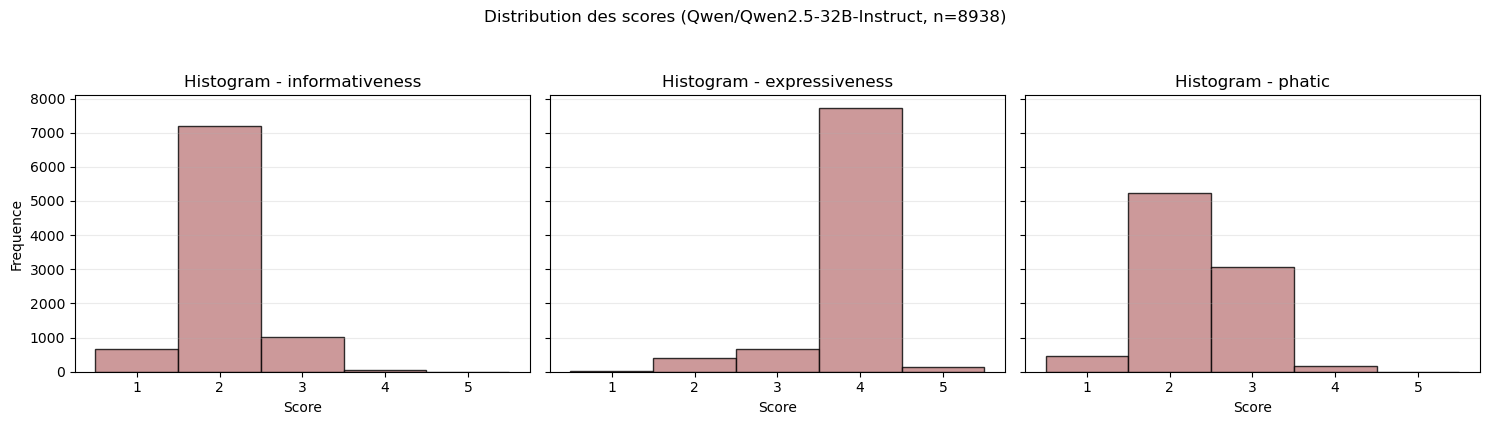

In [21]:
# Reload the score table from disk if it is not already available in memory.
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

# The three communication-function score columns to visualize.
score_cols = ["informativeness", "expressiveness", "phatic"]

plot_df = scores_df.copy()

# Ensure the plotting columns are numeric; invalid values become NaN.
for col in score_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Create one histogram per score dimension, with a shared y-axis for easier comparison.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Bin edges chosen so each integer score from 1 to 5 gets its own bar.
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

for ax, col in zip(axes, score_cols):
    values = plot_df[col].dropna()
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.8, color="#C08081")
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel("Score")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Frequence")

# Add model identity and dataset size to the figure title.
fig.suptitle(f"Distribution des scores ({MODEL_NAME}, n={len(plot_df)})", y=1.05)

hist_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_hist_{len(plot_df)}.png"
fig.savefig(hist_plot_path, dpi=200, bbox_inches="tight")
print("Saved histogram plot:", hist_plot_path)

plt.tight_layout()
plt.show()

plt.show()

## What This Correlation Block Does

This block computes and visualizes the Pearson correlation matrix between the three score dimensions:
- `informativeness`
- `expressiveness`
- `phatic`

It does six things:
1. selects the best available score dataframe
2. converts the score columns to numeric values
3. computes the Pearson correlation matrix
4. displays the matrix as a table
5. renders a heatmap-style visualization
6. saves the correlation plot as a PNG file

This block is useful because it shows whether the model tends to score some dimensions together or independently.

---

## 1. Input source selection

```python
if "plot_df" in globals() and not plot_df.empty:
    corr_source = plot_df.copy()
elif "scores_df" in globals() and not scores_df.empty:
    corr_source = scores_df.copy()
else:
    corr_source = pd.read_csv(csv_scores_path)


Correlation matrix (Pearson):


,informativeness,expressiveness,phatic
informativeness,1.000,-0.281,-0.073
expressiveness,-0.281,1.000,0.188
phatic,-0.073,0.188,1.000


Saved correlation plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_corr_8938.png


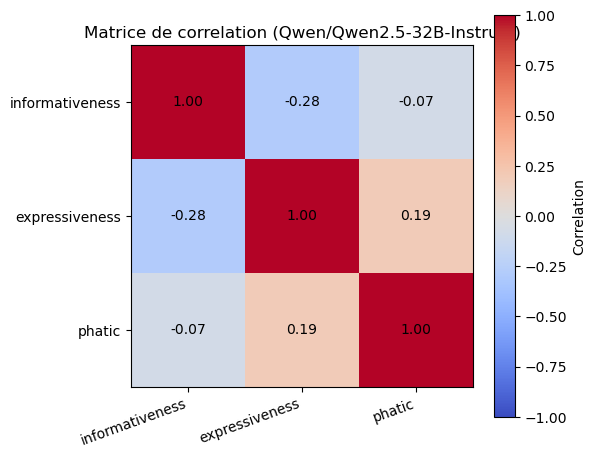

In [22]:
import numpy as np
# Reuse the most prepared dataframe available; fall back to the exported score CSV if needed.
if "plot_df" in globals() and not plot_df.empty:
    corr_source = plot_df.copy()
elif "scores_df" in globals() and not scores_df.empty:
    corr_source = scores_df.copy()
else:
    corr_source = pd.read_csv(csv_scores_path)

# The three score dimensions included in the correlation analysis.
score_cols = ["informativeness", "expressiveness", "phatic"]

# Ensure all score columns are numeric before computing correlations.
for col in score_cols:
    corr_source[col] = pd.to_numeric(corr_source[col], errors="coerce")

# Compute the Pearson correlation matrix across the three score dimensions.
corr_df = corr_source[score_cols].corr(method="pearson")
print("Correlation matrix (Pearson):")
display(corr_df.round(3))

fig, ax = plt.subplots(figsize=(6, 5))

# Heatmap with a fixed -1 to 1 scale so correlations are visually comparable.
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")

ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(score_cols)))
ax.set_xticklabels(score_cols, rotation=20, ha="right")
ax.set_yticklabels(score_cols)
ax.set_title(f"Matrice de correlation ({MODEL_NAME})")

# Print the exact correlation value inside each heatmap cell.
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        value = corr_df.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

corr_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_corr_{len(corr_source)}.png"
fig.savefig(corr_plot_path, dpi=200, bbox_inches="tight")
print("Saved correlation plot:", corr_plot_path)

plt.tight_layout()
plt.show()


## What This Yearly Trend Block Does

This block computes and plots the yearly evolution of the three score dimensions:
- `informativeness`
- `expressiveness`
- `phatic`

It does seven things:
1. loads the score table if needed
2. loads the source dataset if needed
3. recovers the `year` column from the source data
4. merges yearly metadata with the score outputs
5. computes yearly mean scores
6. plots the trends over time
7. saves the yearly trend chart as a PNG file

This block is useful because it shows whether the model reads ad communication style differently across historical periods.

Main Things I Can Change Here
- -- Analytical changes
- use medians instead of means
- add counts per year
- smooth the trend
- compare multiple models on the same chart
- compute separate yearly trends by brand or by EV status

## 1. Input dependencies

```python
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)


,year,informativeness,expressiveness,phatic
0,2014,1.967532,3.668831,2.126623
1,2015,2.045455,3.899621,2.346591
2,2016,2.097595,3.821782,2.362093
3,2017,2.007429,3.841010,2.359584
4,2018,2.046897,3.914483,2.331034
5,2019,1.942308,3.894231,2.289835
6,2020,1.987741,3.732049,2.402802
7,2021,2.074148,3.857715,2.374749
8,2022,2.089056,3.840129,2.298283
9,2023,2.077341,3.858887,2.399593


Saved yearly trend plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_trend_yearly_8938.png


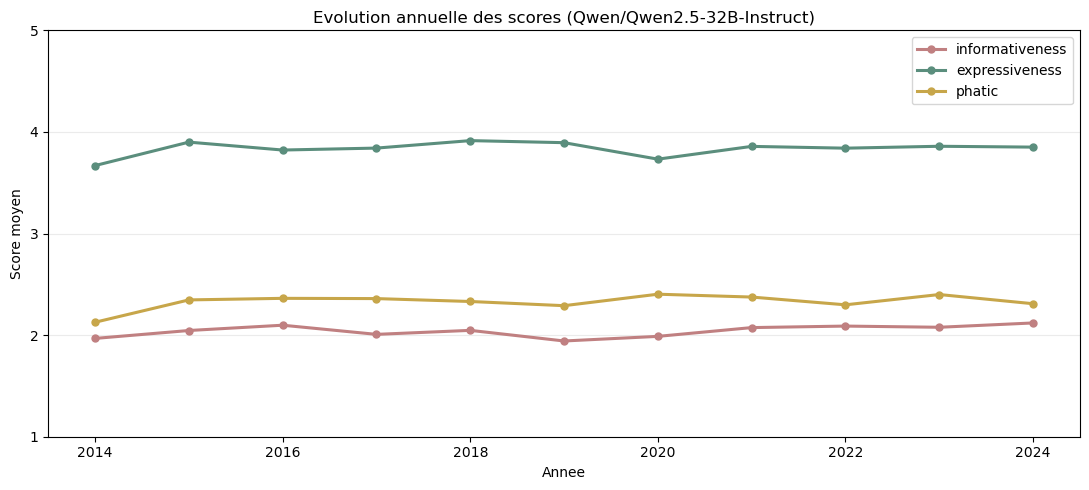

In [23]:
# Reload the score table if it is not already available.
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

# Reload the source dataset if needed so we can recover the year metadata.
if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

# Keep only the identifiers needed to join year information back to the scores.
year_source = df.loc[:, ["row_id", "year"]].copy()
year_source["year"] = pd.to_numeric(year_source["year"], errors="coerce")

# Attach year to each scored row.
yearly_scores_df = scores_df.merge(year_source, on="row_id", how="left")

score_cols = ["informativeness", "expressiveness", "phatic"]

# Ensure the score columns are numeric before averaging.
for col in score_cols:
    yearly_scores_df[col] = pd.to_numeric(yearly_scores_df[col], errors="coerce")

# Keep only rows with a valid year and store year as integer for plotting.
yearly_scores_df = yearly_scores_df.dropna(subset=["year"])
yearly_scores_df["year"] = yearly_scores_df["year"].astype(int)

# Compute yearly mean scores for each communication-function dimension.
yearly_trends_df = (
    yearly_scores_df
    .groupby("year", as_index=False)[score_cols]
    .mean()
    .sort_values("year")
)

display(yearly_trends_df.head(20))

fig, ax = plt.subplots(figsize=(11, 5))

# Fixed colors make comparisons across models and plots easier.
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#5B8E7D",
    "phatic": "#C7A64A",
}

for col in score_cols:
    ax.plot(
        yearly_trends_df["year"],
        yearly_trends_df[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=col,
        color=colors[col],
    )

ax.set_title(f"Evolution annuelle des scores ({MODEL_NAME})")
ax.set_xlabel("Annee")
ax.set_ylabel("Score moyen")
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, axis="y", alpha=0.25)
ax.legend()

trend_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_trend_yearly_{len(yearly_scores_df)}.png"
fig.savefig(trend_plot_path, dpi=200, bbox_inches="tight")
print("Saved yearly trend plot:", trend_plot_path)

plt.tight_layout()
plt.show()

## What This Brand Comparison Block Does

This block compares average scores across the 10 most frequent car brands in the dataset.

It does eight things:
1. loads the score table if needed
2. loads the source dataset if needed
3. recovers the brand column (`Marque`)
4. merges brand metadata with the score outputs
5. keeps only valid brands
6. selects the 10 most frequent brands
7. computes average scores by brand
8. plots a horizontal grouped bar chart and saves it as a PNG file

This block is useful because it shows whether some brands are systematically read by the model as:
- more informative
- more expressive
- more phatic

##### Analytical changes
- use median instead of mean
- sort brands by expressiveness or informativeness
- compare brands by year
- compare only premium vs mass-market brands
- collapse duplicate creatives before averaging


,Marque,informativeness,expressiveness,phatic
4,RENAULT,2.117816,3.744253,2.471264
2,FIAT 500,2.261818,3.832727,2.392727
0,CITROEN C3,2.081633,3.832653,2.444898
3,PEUGEOT 208,1.995349,3.888372,2.823256
8,TOYOTA YARIS,2.140625,3.770833,2.526042
9,VW,1.808743,3.765027,2.666667
6,RENAULT MEGANE,2.160494,3.820988,2.271605
5,RENAULT CLIO,2.006536,3.980392,2.424837
7,RENAULT ZOE,2.189189,3.405405,2.702703
1,DACIA SANDERO,1.856115,3.834532,2.071942


Saved top brands plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_top_brands_2060.png


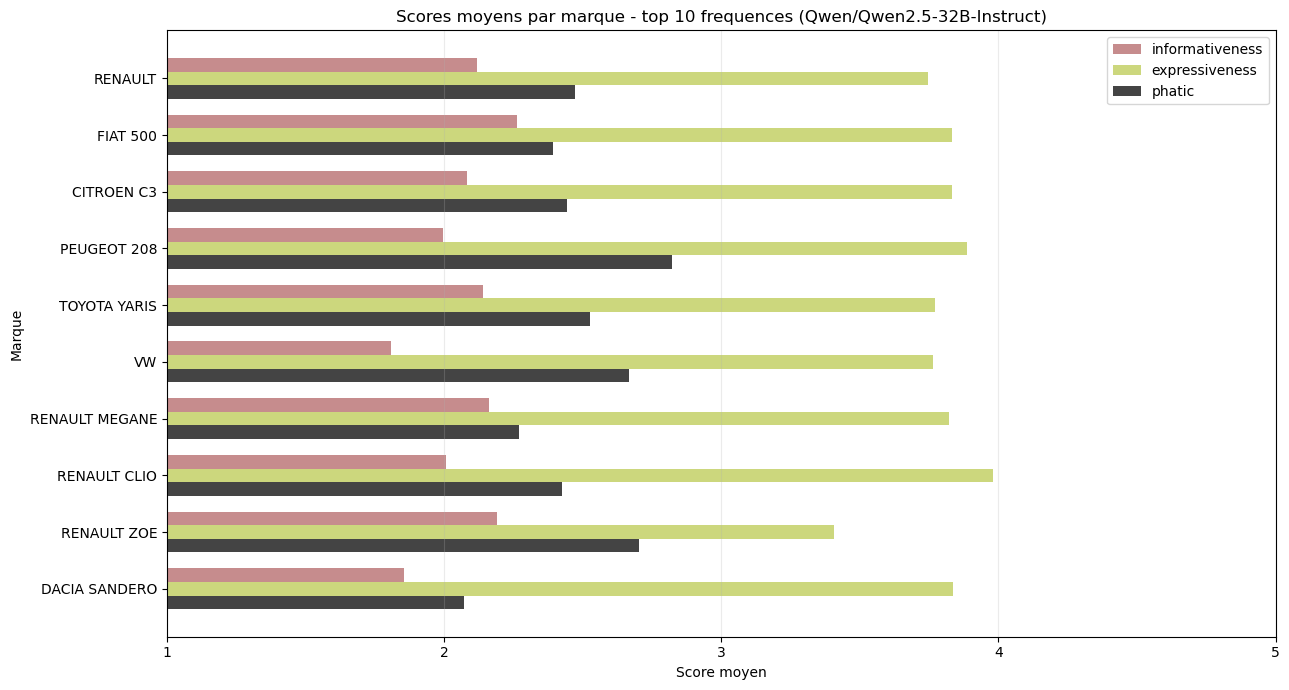

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reload the score table if it is not already available.
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

# Reload the source dataset so we can recover the original brand metadata.
if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

# Keep only the row identifier and brand column for the merge.
brand_source = df.loc[:, ["row_id", "Marque"]].copy()

# Standardize brand names and convert fake missing values into real missing values.
brand_source["Marque"] = brand_source["Marque"].astype(str).str.strip()
brand_source.loc[brand_source["Marque"].isin(["", "nan", "None"]), "Marque"] = pd.NA

# Attach brand information to each scored row.
brand_scores_df = scores_df.merge(brand_source, on="row_id", how="left")

score_cols = ["informativeness", "expressiveness", "phatic"]

# Ensure the score columns are numeric before aggregation.
for col in score_cols:
    brand_scores_df[col] = pd.to_numeric(brand_scores_df[col], errors="coerce")

# Keep only rows with a valid brand, then focus on the 10 most frequent brands.
brand_scores_df = brand_scores_df.dropna(subset=["Marque"])
top_brands = brand_scores_df["Marque"].value_counts().head(10).index.tolist()
brand_scores_df = brand_scores_df[brand_scores_df["Marque"].isin(top_brands)].copy()

# Compute average scores by brand.
brand_trends_df = (
    brand_scores_df
    .groupby("Marque", as_index=False)[score_cols]
    .mean()
)

# Preserve the top-brand order by frequency instead of sorting alphabetically.
brand_trends_df["brand_rank"] = pd.Categorical(brand_trends_df["Marque"], categories=top_brands, ordered=True)
brand_trends_df = brand_trends_df.sort_values("brand_rank").drop(columns=["brand_rank"])

display(brand_trends_df)

fig, ax = plt.subplots(figsize=(13, 7))

# Fixed colors help comparison across runs and across dimensions.
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#C7D36F",
    "phatic": "#2F2F2F",
}

y = np.arange(len(brand_trends_df))
bar_height = 0.24
offsets = {
    "informativeness": -bar_height,
    "expressiveness": 0.0,
    "phatic": bar_height,
}

# Draw grouped horizontal bars so all three dimensions are visible for each brand.
for col in score_cols:
    ax.barh(
        y + offsets[col],
        brand_trends_df[col],
        height=bar_height,
        label=col,
        color=colors[col],
        alpha=0.9,
    )

ax.set_title(f"Scores moyens par marque - top 10 frequences ({MODEL_NAME})")
ax.set_xlabel("Score moyen")
ax.set_ylabel("Marque")
ax.set_xlim(1, 5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks(y)
ax.set_yticklabels(brand_trends_df["Marque"])
ax.grid(True, axis="x", alpha=0.25)
ax.legend()
ax.invert_yaxis()

brand_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_top_brands_{len(brand_scores_df)}.png"
fig.savefig(brand_plot_path, dpi=200, bbox_inches="tight")
print("Saved top brands plot:", brand_plot_path)

plt.tight_layout()
plt.show()


## What This EV / Non-EV Block Does

This block compares average communication-function scores between:
- electrified ads
- non-electrified ads

It does eight things:
1. loads the score table if needed
2. loads the source dataset if needed
3. recovers the `Electric` and `Hybrid` columns
4. creates a boolean `is_electrified` flag
5. merges electrification metadata with the score outputs
6. computes average scores by electrification segment
7. plots a grouped horizontal bar chart
8. saves the figure as a PNG file

This block is useful because it tests whether the model reads electrified ads differently from other ads.


,is_electrified,informativeness,expressiveness,phatic,segment
0,False,2.024888,3.828827,2.346822,Non electrified
1,True,2.100209,3.858038,2.303012,Electrified


Saved EV split plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_ev_split_8938.png


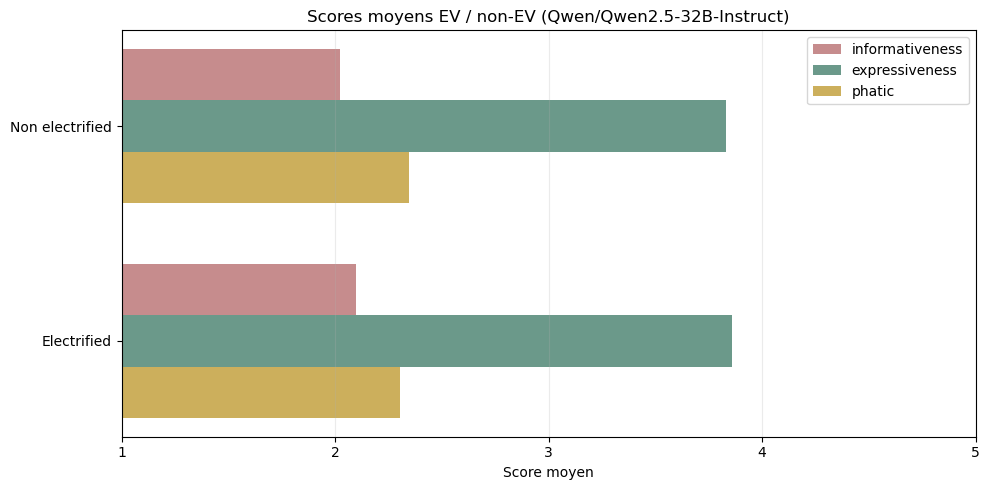

In [25]:
#Reload the score table if it is not already available.
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

# Reload the source dataset so we can recover EV-related metadata.
if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

# Keep only the identifier and the EV / hybrid indicator columns.
ev_source = df.loc[:, ["row_id", "Electric", "Hybrid"]].copy()

# Convert indicators to numeric and treat missing values as zero.
ev_source["Electric"] = pd.to_numeric(ev_source["Electric"], errors="coerce").fillna(0)
ev_source["Hybrid"] = pd.to_numeric(ev_source["Hybrid"], errors="coerce").fillna(0)

# A row is treated as electrified if it is electric or hybrid.
ev_source["is_electrified"] = (ev_source["Electric"] > 0) | (ev_source["Hybrid"] > 0)

# Attach the electrification flag to each scored row.
ev_scores_df = scores_df.merge(ev_source[["row_id", "is_electrified"]], on="row_id", how="left")

score_cols = ["informativeness", "expressiveness", "phatic"]

# Ensure score columns are numeric before aggregation.
for col in score_cols:
    ev_scores_df[col] = pd.to_numeric(ev_scores_df[col], errors="coerce")

# Compute average scores for electrified vs non-electrified ads.
ev_summary_df = (
    ev_scores_df
    .groupby("is_electrified", as_index=False)[score_cols]
    .mean()
    .sort_values("is_electrified")
)

# Replace boolean values with readable segment labels for plotting.
ev_summary_df["segment"] = ev_summary_df["is_electrified"].map({False: "Non electrified", True: "Electrified"})
display(ev_summary_df)

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(ev_summary_df))
bar_height = 0.24
offsets = {"informativeness": -bar_height, "expressiveness": 0.0, "phatic": bar_height}
colors = {"informativeness": "#C08081", "expressiveness": "#5B8E7D", "phatic": "#C7A64A"}

# Draw grouped horizontal bars so the three score dimensions can be compared per segment.
for col in score_cols:
    ax.barh(
        y + offsets[col],
        ev_summary_df[col],
        height=bar_height,
        label=col,
        color=colors[col],
        alpha=0.9,
    )

ax.set_title(f"Scores moyens EV / non-EV ({MODEL_NAME})")
ax.set_xlabel("Score moyen")
ax.set_xlim(1, 5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks(y)
ax.set_yticklabels(ev_summary_df["segment"])
ax.grid(True, axis="x", alpha=0.25)
ax.legend()
ax.invert_yaxis()

ev_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_ev_split_{len(ev_scores_df)}.png"
fig.savefig(ev_plot_path, dpi=200, bbox_inches="tight")
print("Saved EV split plot:", ev_plot_path)

plt.tight_layout()
plt.show()

## What This Duplicate-Creative Diagnostic Block Does

This block studies whether the model’s average scores change depending on how often the same `Visuel` description is repeated in the dataset.

It does nine things:
1. loads the score table if needed
2. loads the source dataset if needed
3. recovers the `Visuel` text from the source data
4. merges `Visuel` back onto the score outputs
5. counts how often each `Visuel` appears
6. assigns each row to a duplicate-frequency bucket
7. computes mean scores by bucket
8. prints dataset-level duplicate statistics
9. plots the score trend across duplicate buckets and saves the figure

This block is useful because your dataset contains many repeated creatives, and repeated rows can distort average score patterns.

,duplicate_bucket,informativeness,expressiveness,phatic
0,1,2.054632,3.627078,2.199525
2,2-5,2.074464,3.806628,2.298246
3,6-10,2.055096,3.887052,2.332874
1,11+,2.035192,3.887862,2.386221


Unique Visuel descriptions: 2165
Share of rows in repeated Visuel groups: 90.58%
Saved duplicate diagnostics plot: /home/cbenavent/test/Arcom_rares/latex/qwen_qwen2_5_32b_instruct__scores_duplicate_diagnostics_8938.png


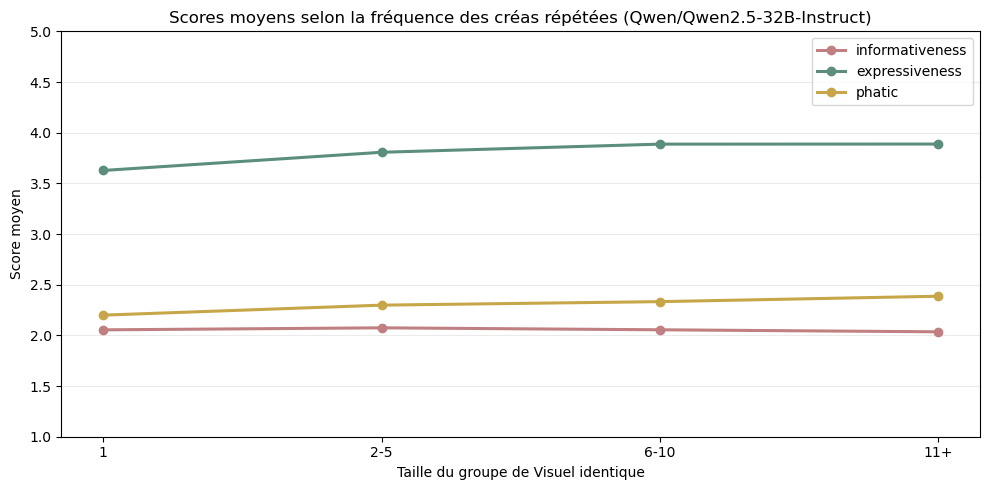

In [26]:
# --- Duplicate-creative diagnostics ---
# Reload the score table if it is not already available.
if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

# Reload the source dataset so we can recover the original Visuel descriptions.
if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

# Keep only the identifier and the Visuel field for duplicate analysis.
dup_source = df.loc[:, ["row_id", "Visuel"]].copy()

# Standardize Visuel text and convert fake missing values into real missing values.
dup_source["Visuel"] = dup_source["Visuel"].astype(str).str.strip()
dup_source.loc[dup_source["Visuel"].isin(["", "nan", "None"]), "Visuel"] = pd.NA

# Attach Visuel text back to the scored rows.
dup_scores_df = scores_df.merge(dup_source, on="row_id", how="left")

score_cols = ["informativeness", "expressiveness", "phatic"]

# Ensure score columns are numeric before aggregation.
for col in score_cols:
    dup_scores_df[col] = pd.to_numeric(dup_scores_df[col], errors="coerce")

# Count how many times each exact Visuel description appears in the dataset.
visuel_counts = dup_scores_df["Visuel"].value_counts(dropna=True)
dup_scores_df["visuel_count"] = dup_scores_df["Visuel"].map(visuel_counts)
dup_scores_df["visuel_count"] = dup_scores_df["visuel_count"].fillna(1)

def bucket_count(n):
    # Bucket duplicate-group sizes into broad categories for easier plotting.
    n = int(n)
    if n == 1:
        return "1"
    if n <= 5:
        return "2-5"
    if n <= 10:
        return "6-10"
    return "11+"

dup_scores_df["duplicate_bucket"] = dup_scores_df["visuel_count"].apply(bucket_count)
order = ["1", "2-5", "6-10", "11+"]

# Compute average scores within each duplicate-frequency bucket.
dup_summary_df = (
    dup_scores_df
    .groupby("duplicate_bucket", as_index=False)[score_cols]
    .mean()
)
dup_summary_df["duplicate_bucket"] = pd.Categorical(dup_summary_df["duplicate_bucket"], categories=order, ordered=True)
dup_summary_df = dup_summary_df.sort_values("duplicate_bucket")
display(dup_summary_df)

# Useful dataset-level diagnostics about creative repetition.
unique_visuels = dup_scores_df["Visuel"].dropna().nunique()
repeated_share = float((dup_scores_df["visuel_count"] > 1).mean()) * 100.0
print(f"Unique Visuel descriptions: {unique_visuels}")
print(f"Share of rows in repeated Visuel groups: {repeated_share:.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot score means across duplicate-frequency buckets.
for col, color in [("informativeness", "#C08081"), ("expressiveness", "#5B8E7D"), ("phatic", "#C7A64A")]:
    ax.plot(
        dup_summary_df["duplicate_bucket"].astype(str),
        dup_summary_df[col],
        marker="o",
        linewidth=2.2,
        markersize=6,
        label=col,
        color=color,
    )

ax.set_title(f"Scores moyens selon la fréquence des créas répétées ({MODEL_NAME})")
ax.set_xlabel("Taille du groupe de Visuel identique")
ax.set_ylabel("Score moyen")
ax.set_ylim(1, 5)
ax.grid(True, axis="y", alpha=0.25)
ax.legend()

dup_plot_path = PROJECT_ROOT / "latex" / f"{MODEL_SLUG}__scores_duplicate_diagnostics_{len(dup_scores_df)}.png"
fig.savefig(dup_plot_path, dpi=200, bbox_inches="tight")
print("Saved duplicate diagnostics plot:", dup_plot_path)

plt.tight_layout()
plt.show()
